# Visualizador de Eventos DRS4 — Muones

Este notebook permite seleccionar e inspeccionar cualquier archivo y evento de la carpeta `muones/data_otros/`.

### Funcionalidades:
- **Selector de archivo**: detecta y lista automáticamente los archivos disponibles en `data_otros/`.
- **Selector de evento**: permite elegir el evento por menú desplegable, control deslizante (*slider*) o botones *Anterior* / *Siguiente*.
- **Modos de gráfico**:
  - **Subplots independientes**: cada canal en su propio panel con eje de tiempo $t$ alineado (`sharex=True`).
  - **Superpuesto**: todos los canales en el mismo gráfico para comparar amplitudes y retardos.
- **Filtro de canales**: activación / desactivación individual de canales (`u1`, `u2`, `u3`, etc.).
- **Zoom temporal**: control de rango $[t_{\min}, t_{\max}]$ o visualización de barrido completo.
- **Métricas del evento**: tabla resumen con tensiones mínimas (picos), tiempos y amplitudes relativas.

In [9]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# Estilo de gráficos
try:
    plt.style.use('seaborn-v0_8')
except Exception:
    plt.style.use('default')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'legend.fontsize': 11,
    'legend.frameon': True,
})


## Funciones de lectura y graficación

In [10]:
def obtener_directorio_datos():
    """Localiza la carpeta de datos de muones."""
    candidatos = [
        Path('../data_otros'),
        Path('muones/data_otros'),
        Path('data_otros'),
    ]
    for p in candidatos:
        if p.exists() and p.is_dir():
            return p.resolve()
    return Path('../data_otros').resolve()


def listar_archivos(directorio=None):
    """Lista archivos de datos en el directorio."""
    if directorio is None:
        directorio = obtener_directorio_datos()
    directorio = Path(directorio)
    if not directorio.exists():
        return []
    return sorted([f for f in directorio.iterdir() if f.is_file() and not f.name.startswith('.')])


_CACHE_INDICE = {}


def indexar_archivo(filepath):
    """Indexa los offsets de los eventos para acceso rápido sin sobrecargar la memoria."""
    filepath = Path(filepath).resolve()
    if filepath in _CACHE_INDICE:
        return _CACHE_INDICE[filepath]

    eventos = []
    columnas = None
    meta = {}

    with open(filepath, 'rb') as f:
        pos = 0
        line = f.readline()
        while line:
            line_str = line.decode('utf-8', errors='replace').strip()
            if line_str.startswith('#'):
                if 'Columns:' in line_str and columnas is None:
                    columnas = line_str.split('Columns:')[1].split()
                elif 'run_id=' in line_str:
                    meta['run_id'] = line_str.split('run_id=')[-1].strip()
            elif line_str.startswith('Event #'):
                m = re.search(r'Event #(\d+)', line_str)
                num_ev = int(m.group(1)) if m else len(eventos)
                eventos.append({
                    'indice': len(eventos),
                    'num_evento': num_ev,
                    'header': line_str,
                    'offset': pos,
                })
            elif line_str.startswith('t[') and columnas is None:
                columnas = line_str.split()
            pos = f.tell()
            line = f.readline()

    if columnas is None:
        columnas = ['t[ns]', 'u1[mV]', 'u2[mV]', 'u3[mV]']

    resultado = (eventos, columnas, meta)
    _CACHE_INDICE[filepath] = resultado
    return resultado


def leer_evento(filepath, offset, columnas):
    """Lee un único evento desde su posición de byte en disco."""
    with open(filepath, 'rb') as f:
        f.seek(offset)
        header = f.readline().decode('utf-8', errors='replace').strip()
        data = []
        next_pos = f.tell()
        line = f.readline().decode('utf-8', errors='replace').strip()
        if not line.startswith('t['):
            f.seek(next_pos)

        for line in f:
            line_str = line.decode('utf-8', errors='replace').strip()
            if not line_str or line_str.startswith('Event #'):
                break
            parts = line_str.split()
            if parts:
                try:
                    data.append([float(x) for x in parts])
                except ValueError:
                    pass

    cols = columnas if (data and len(data[0]) == len(columnas)) else None
    df = pd.DataFrame(data, columns=cols)
    return header, df


def calcular_metricas(df, columnas_canales, t_col='t[ns]'):
    """Calcula amplitud mínima, tiempo de pico y línea de base aproximada."""
    t = df[t_col].values
    res = []
    for ch in columnas_canales:
        v = df[ch].values
        if len(v) == 0:
            continue
        idx_min = int(np.argmin(v))
        n_base = max(10, min(50, len(v) // 10))
        base = float(np.median(v[:n_base]))
        v_min = float(v[idx_min])
        t_min = float(t[idx_min])
        amp = abs(v_min - base)

        res.append({
            'Canal': ch,
            'V_mín [mV]': f'{v_min:+.1f}',
            't @ V_mín [ns]': f'{t_min:.1f}',
            'V_máx [mV]': f'{float(v.max()):+.1f}',
            'Línea base aprox [mV]': f'{base:+.1f}',
            'Amplitud pico [mV]': f'{amp:.1f}',
        })
    return pd.DataFrame(res)


COLORES_CANALES = {
    'u1[mV]': '#1f77b4',
    'u2[mV]': '#ff7f0e',
    'u3[mV]': '#2ca02c',
    'u4[mV]': '#d62728',
}
PALETA_DEFAULT = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']


def graficar_evento(filepath, offset, columnas, canales=None, modo='subplots', t_rango=None, marcar_picos=True):
    """Grafica el trazo temporal de un evento DRS4."""
    header, df = leer_evento(filepath, offset, columnas)
    if df.empty:
        fig, ax = plt.subplots(figsize=(8, 2))
        ax.text(0.5, 0.5, 'Sin datos en el evento seleccionado', ha='center', va='center')
        return fig, df

    t_col = df.columns[0]
    todos_canales = [c for c in df.columns if c != t_col]
    if canales is None:
        canales = todos_canales
    else:
        canales = [c for c in canales if c in todos_canales]

    if not canales:
        fig, ax = plt.subplots(figsize=(8, 2))
        ax.text(0.5, 0.5, 'Seleccione al menos un canal', ha='center', va='center')
        return fig, df

    t = df[t_col].values
    nombre_archivo = Path(filepath).name

    if modo == 'subplots':
        n_canales = len(canales)
        fig, axes = plt.subplots(n_canales, 1, sharex=True, figsize=(11, max(3.0, 2.3 * n_canales)), squeeze=False)
        axes_list = axes[:, 0]

        for i, ch in enumerate(canales):
            ax = axes_list[i]
            col = COLORES_CANALES.get(ch, PALETA_DEFAULT[i % len(PALETA_DEFAULT)])
            v = df[ch].values
            ax.plot(t, v, color=col, lw=1.2, label=ch)

            if marcar_picos:
                idx_min = int(np.argmin(v))
                ax.plot(t[idx_min], v[idx_min], marker='o', color='red', markersize=5,
                        label=f'Pico: {v[idx_min]:.1f} mV @ {t[idx_min]:.1f} ns')
                print(t[idx_min])

            ax.set_ylabel(ch)
            ax.grid(True, alpha=0.4, linestyle='--')
            ax.axhline(0, color='gray', lw=0.6, linestyle=':')
            ax.legend(loc='upper right', framealpha=0.85)

            if t_rango is not None:
                ax.set_xlim(t_rango)

        axes_list[-1].set_xlabel(t_col)
        fig.suptitle(f'{header}\nArchivo: {nombre_archivo}', y=0.99)
        fig.tight_layout()

    else:  # Modo 'superpuesto'
        fig, ax = plt.subplots(figsize=(11, 5.5))
        for i, ch in enumerate(canales):
            col = COLORES_CANALES.get(ch, PALETA_DEFAULT[i % len(PALETA_DEFAULT)])
            v = df[ch].values
            ax.plot(t, v, color=col, lw=1.2, label=ch)
            if marcar_picos:
                idx_min = int(np.argmin(v))
                ax.plot(t[idx_min], v[idx_min], marker='o', color=col, markersize=5, markeredgecolor='black')

        ax.set_xlabel(t_col)
        ax.set_ylabel('Tensión [mV]')
        ax.grid(True, alpha=0.4, linestyle='--')
        ax.axhline(0, color='gray', lw=0.6, linestyle=':')
        ax.legend(loc='upper right', framealpha=0.85)
        if t_rango is not None:
            ax.set_xlim(t_rango)
        ax.set_title(f'{header}\nArchivo: {nombre_archivo}')
        fig.tight_layout()

    return fig, df


## Interfaz Interactiva
Ejecutá la siguiente celda para abrir el visor interactivo. Podés cambiar de archivo, avanzar entre eventos, ajustar el zoom temporal y alternar canales o modos de vista.

In [11]:
def visor_interactivo():
    data_dir = obtener_directorio_datos()
    archivos = listar_archivos(data_dir)

    if not archivos:
        print(f'⚠️ No se encontraron archivos de datos en: {data_dir}')
        return

    # Widgets
    w_archivo = widgets.Dropdown(
        options=[(f.name, f) for f in archivos],
        value=archivos[0],
        description='Archivo:',
        layout=widgets.Layout(width='430px')
    )

    w_btn_refrescar = widgets.Button(
        description='🔄 Refrescar',
        tooltip='Escanear nuevos archivos en la carpeta',
        layout=widgets.Layout(width='110px')
    )

    w_evento_dropdown = widgets.Dropdown(
        description='Evento:',
        layout=widgets.Layout(width='470px')
    )

    w_slider_evento = widgets.IntSlider(
        value=1, min=1, max=1, step=1,
        description='N° Orden:',
        continuous_update=False,
        layout=widgets.Layout(width='360px')
    )

    w_btn_prev = widgets.Button(description='◀ Anterior', layout=widgets.Layout(width='100px'))
    w_btn_next = widgets.Button(description='Siguiente ▶', layout=widgets.Layout(width='100px'))

    w_modo = widgets.RadioButtons(
        options=[('Subplots (un panel por canal)', 'subplots'), ('Superpuesto (un solo panel)', 'superpuesto')],
        value='subplots',
        description='Modo:',
        layout=widgets.Layout(width='320px')
    )

    w_marcar_pico = widgets.Checkbox(value=True, description='Marcar picos mínimos', indent=False, layout=widgets.Layout(width='180px'))
    w_rango_completo = widgets.Checkbox(value=True, description='Rango t completo', indent=False, layout=widgets.Layout(width='180px'))

    w_t_slider = widgets.FloatRangeSlider(
        value=[0.0, 1000.0], min=0.0, max=1700.0, step=10.0,
        description='Rango t [ns]:',
        disabled=True,
        continuous_update=False,
        layout=widgets.Layout(width='460px')
    )

    w_canales_box = widgets.HBox([], layout=widgets.Layout(margin='0 0 10px 0'))

    out_grafico = widgets.Output()
    out_metricas = widgets.Output()

    estado = {
        'eventos': [],
        'columnas': [],
        'meta': {},
        'canales_checks': {},
        'bloqueo_sync': False,
    }

    def actualizar_canales_checkboxes(columnas):
        t_col = columnas[0]
        canales = [c for c in columnas if c != t_col]
        checks = {}
        items = []
        for ch in canales:
            cb = widgets.Checkbox(value=True, description=ch, indent=False, layout=widgets.Layout(width='90px'))
            cb.observe(lambda change: actualizar_grafico(), names='value')
            checks[ch] = cb
            items.append(cb)
        estado['canales_checks'] = checks
        w_canales_box.children = [widgets.Label('Canales:')] + items

    def cargar_archivo_seleccionado():
        archivo_actual = w_archivo.value
        eventos, columnas, meta = indexar_archivo(archivo_actual)
        estado['eventos'] = eventos
        estado['columnas'] = columnas
        estado['meta'] = meta

        actualizar_canales_checkboxes(columnas)

        if not eventos:
            w_evento_dropdown.options = [('Sin eventos', None)]
            w_slider_evento.max = 1
            w_slider_evento.value = 1
            return

        opciones = [
            (f"[{ev['indice']+1}/{len(eventos)}] {ev['header']}", ev['offset']) for ev in eventos
        ]

        estado['bloqueo_sync'] = True
        w_evento_dropdown.options = opciones
        w_evento_dropdown.value = eventos[0]['offset']
        w_slider_evento.min = 1
        w_slider_evento.max = len(eventos)
        w_slider_evento.value = 1
        estado['bloqueo_sync'] = False

        _, df_temp = leer_evento(archivo_actual, eventos[0]['offset'], columnas)
        if not df_temp.empty:
            t_vals = df_temp[columnas[0]].values
            t_min = float(np.floor(t_vals.min()))
            t_max = float(np.ceil(t_vals.max()))
            w_t_slider.min = t_min
            w_t_slider.max = t_max
            w_t_slider.value = [t_min, t_max]

    def actualizar_grafico():
        if not estado['eventos'] or w_evento_dropdown.value is None:
            return

        offset = w_evento_dropdown.value
        filepath = w_archivo.value
        columnas = estado['columnas']
        canales_sel = [ch for ch, cb in estado['canales_checks'].items() if cb.value]
        t_rango = None if w_rango_completo.value else tuple(w_t_slider.value)
        modo = w_modo.value
        marcar_picos = w_marcar_pico.value

        with out_grafico:
            clear_output(wait=True)
            fig, df_ev = graficar_evento(
                filepath, offset, columnas,
                canales=canales_sel, modo=modo,
                t_rango=t_rango, marcar_picos=marcar_picos
            )
            plt.show()

        with out_metricas:
            clear_output(wait=True)
            if not df_ev.empty and canales_sel:
                df_metricas = calcular_metricas(df_ev, canales_sel, t_col=estado['columnas'][0])
                display(df_metricas)

    def on_archivo_change(change):
        cargar_archivo_seleccionado()
        actualizar_grafico()

    def on_evento_dropdown_change(change):
        if estado['bloqueo_sync'] or change['new'] is None:
            return
        estado['bloqueo_sync'] = True
        for ev in estado['eventos']:
            if ev['offset'] == change['new']:
                w_slider_evento.value = ev['indice'] + 1
                break
        estado['bloqueo_sync'] = False
        actualizar_grafico()

    def on_slider_change(change):
        if estado['bloqueo_sync']:
            return
        estado['bloqueo_sync'] = True
        idx = change['new'] - 1
        if 0 <= idx < len(estado['eventos']):
            w_evento_dropdown.value = estado['eventos'][idx]['offset']
        estado['bloqueo_sync'] = False
        actualizar_grafico()

    def on_btn_prev_click(b):
        if w_slider_evento.value > w_slider_evento.min:
            w_slider_evento.value -= 1

    def on_btn_next_click(b):
        if w_slider_evento.value < w_slider_evento.max:
            w_slider_evento.value += 1

    def on_rango_completo_change(change):
        w_t_slider.disabled = change['new']
        actualizar_grafico()

    def on_refrescar_archivos(b):
        nuevos = listar_archivos()
        if nuevos:
            w_archivo.options = [(f.name, f) for f in nuevos]
            if w_archivo.value not in nuevos:
                w_archivo.value = nuevos[0]
            cargar_archivo_seleccionado()
            actualizar_grafico()

    w_archivo.observe(on_archivo_change, names='value')
    w_btn_refrescar.on_click(on_refrescar_archivos)
    w_evento_dropdown.observe(on_evento_dropdown_change, names='value')
    w_slider_evento.observe(on_slider_change, names='value')
    w_btn_prev.on_click(on_btn_prev_click)
    w_btn_next.on_click(on_btn_next_click)
    w_modo.observe(lambda c: actualizar_grafico(), names='value')
    w_marcar_pico.observe(lambda c: actualizar_grafico(), names='value')
    w_rango_completo.observe(on_rango_completo_change, names='value')
    w_t_slider.observe(lambda c: actualizar_grafico(), names='value')

    # Disposición visual
    fila_archivo = widgets.HBox([w_archivo, w_btn_refrescar], layout=widgets.Layout(align_items='center'))
    fila_evento = widgets.HBox([w_evento_dropdown, w_btn_prev, w_btn_next], layout=widgets.Layout(align_items='center'))
    fila_slider = widgets.HBox([w_slider_evento])
    fila_tiempo = widgets.HBox([w_rango_completo, w_t_slider], layout=widgets.Layout(align_items='center'))
    fila_opciones = widgets.HBox([w_modo, widgets.VBox([w_marcar_pico, w_canales_box])], layout=widgets.Layout(align_items='flex-start', margin='5px 0'))

    panel_controles = widgets.VBox([
        widgets.HTML("<h3>🛠️ Panel de Control de Eventos DRS4</h3><hr style='margin-top:2px; margin-bottom:8px;'>"),
        fila_archivo,
        fila_evento,
        fila_slider,
        fila_opciones,
        fila_tiempo
    ], layout=widgets.Layout(padding='12px', border='1px solid #d0d7de', border_radius='8px', margin='0 0 15px 0'))

    panel_metricas = widgets.VBox([
        widgets.HTML("<h4>📊 Métricas y Picos del Evento</h4><hr style='margin-top:2px; margin-bottom:6px;'>"),
        out_metricas
    ], layout=widgets.Layout(padding='8px 12px', border='1px solid #e1e4e8', border_radius='6px', margin='10px 0'))

    cargar_archivo_seleccionado()
    actualizar_grafico()

    display(panel_controles)
    display(out_grafico)
    display(panel_metricas)

visor_interactivo()


Output()

---
## Uso Programático (opcional)
Si necesitás procesar eventos desde un script o en bucle sin interfaz gráfica, podés usar directamente las funciones:

Archivos encontrados: ['run_20260911_135116_idx0_selected.txt']
Archivo: run_20260911_135116_idx0_selected.txt — Total de eventos: 142
Graficando evento #2: Event #2  ts=2026-09-11 13:51:20.406  [SELECTED]
224.121
224.121
224.121


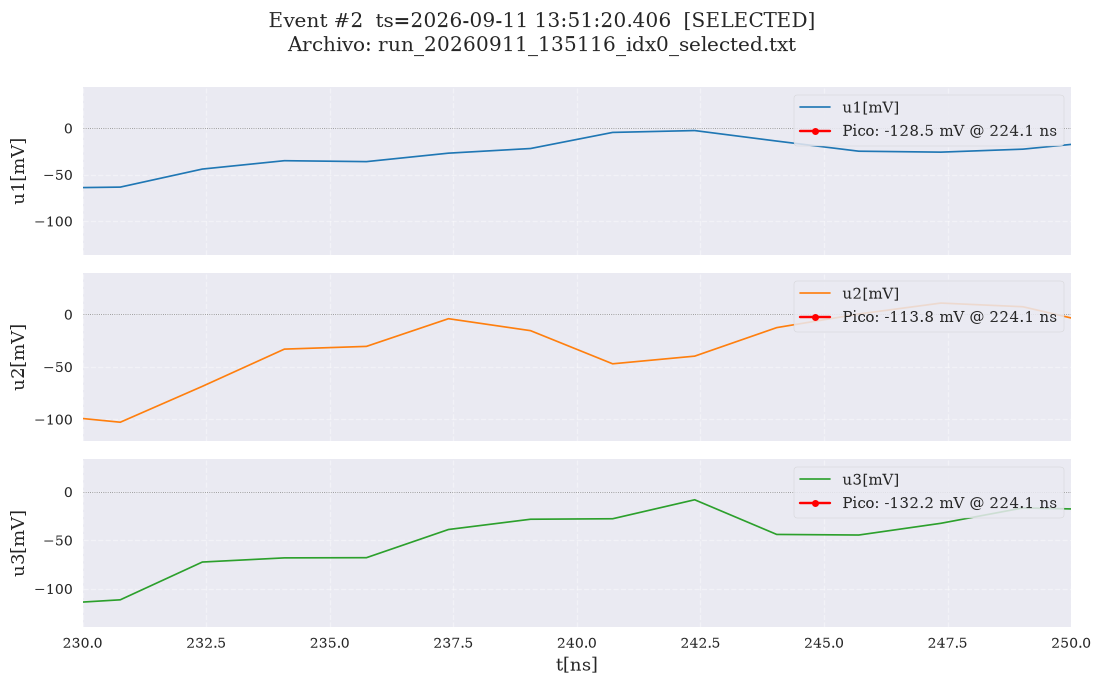

,Canal,V_mín [mV],t @ V_mín [ns],V_máx [mV],Línea base aprox [mV],Amplitud pico [mV]
0,u1[mV],-128.5,224.1,+35.8,-6.6,121.9
1,u2[mV],-113.8,224.1,+31.9,-12.5,101.3
2,u3[mV],-132.2,224.1,+25.6,-9.5,122.7


In [15]:
# 1. Obtener archivos
archivos = listar_archivos()
print(f"Archivos encontrados: {[f.name for f in archivos]}")

if archivos:
    archivo = archivos[0]
    eventos, columnas, meta = indexar_archivo(archivo)
    print(f"Archivo: {archivo.name} — Total de eventos: {len(eventos)}")

    # 2. Elegir un evento por índice (ej: evento 0)
    ev = eventos[0]
    print(f"Graficando evento #{ev['num_evento']}: {ev['header']}")

    fig, df_ev = graficar_evento(
        filepath=archivo,
        offset=ev['offset'],
        columnas=columnas,
        modo='subplots',  # o 'superpuesto'
        marcar_picos=True
    )
    plt.xlim(230, 250)
    plt.show()

    # 3. Métricas
    display(calcular_metricas(df_ev, [c for c in df_ev.columns if c != 't[ns]']))
